In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3

In [3]:
from upvfab_design_tools import MMI_EME, DC_EME

# 1. Simulating Propagation Modes in SOI Waveguides

### 1. Define the SOI waveguide structure

The first step consists in defining the simulation grid resolution used by the electromagnetic mode solver.
This parameter controls the spatial discretization of the computational domain and therefore influences the trade-off between simulation accuracy and computational time

In [9]:
waveguide_Grid_Resolution = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

In [10]:
step_size = 5
grid_resolution = np.arange(10, 100 + step_size, step_size)
sweep_waveguide_Grid_Resolution = gt.modes.sweep_n_eff(waveguide_Grid_Resolution, 
                             grid_resolution=grid_resolution)

  0%|          | 0/19 [00:00<?, ?it/s]

2026-05-09 14:49:19.593 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c02103117cd3353d.npz.
2026-05-09 14:49:19.599 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_64535e103585b92c.npz.
2026-05-09 14:49:19.601 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_db7a43f98d148721.npz.
2026-05-09 14:49:19.603 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ede4395ffc39f9b9.npz.
2026-05-09 14:49:19.607 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4bdfbf831b17a631.npz.
2026-05-09 14:49:19.610 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d193b2e2ca7e24e8.npz.
2026-05-09 14:49:19.613 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5cb34e7bb1c6d7d6.npz.
2026-05-09 14:49:19.615 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_96e39e925de1c3b2.npz.


In [11]:
neff_mean = np.mean(sweep_waveguide_Grid_Resolution)

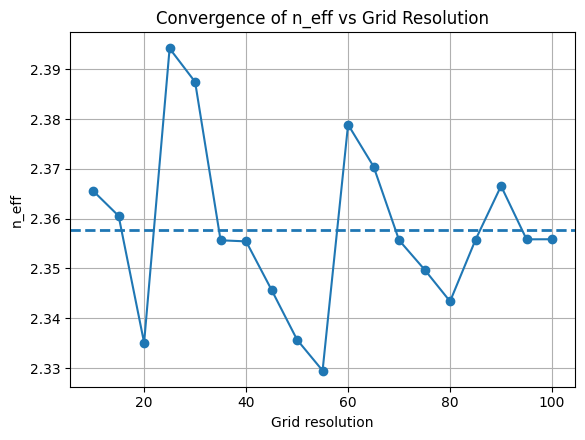

In [12]:
plt.figure(figsize=(7, 4.5))
plt.plot(grid_resolution, sweep_waveguide_Grid_Resolution.real, marker='o')
plt.axhline(neff_mean.real, linestyle='--', linewidth=2)
plt.xlabel("Grid resolution")
plt.ylabel("n_eff")
plt.title("Convergence of n_eff vs Grid Resolution")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])

In [13]:
waveguide_Grid_Scaling = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

In [15]:
step_size = 0.1
max_grid_scaling = np.arange(1.2, 1.6 + step_size, step_size)
sweep_waveguide_Grid_Scaling = gt.modes.sweep_n_eff(waveguide_Grid_Scaling, 
                             max_grid_scaling=max_grid_scaling)

  0%|          | 0/6 [00:00<?, ?it/s]

2026-05-09 14:55:56.575 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9efc89966753b23b.npz.
2026-05-09 14:55:56.577 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fcef14e0c30fac31.npz.
2026-05-09 14:55:56.579 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_704870f0460d98a2.npz.
2026-05-09 14:55:56.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f5862cb3c7a29cc5.npz.
2026-05-09 14:55:56.582 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dcf42c1c9b2dbb70.npz.
2026-05-09 14:55:56.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_febd4b6ce0d70c7c.npz.


In [16]:
mask = sweep_waveguide_Grid_Scaling.real > 2.375
max_grid_scaling_filtered = max_grid_scaling[mask]
neff_filtered = sweep_waveguide_Grid_Scaling.real[mask]
neff_mean = np.mean(neff_filtered)

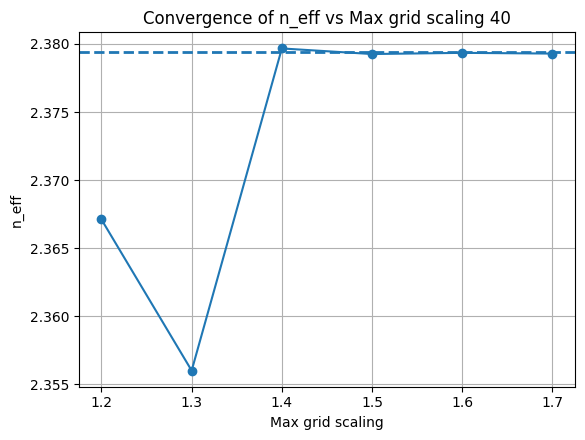

In [17]:
plt.figure(figsize=(7, 4.5))
plt.plot(max_grid_scaling, sweep_waveguide_Grid_Scaling.real, marker='o')
plt.axhline(neff_mean, linestyle='--', linewidth=2)
plt.xlabel("Max grid scaling")
plt.ylabel("n_eff")
plt.title("Convergence of n_eff vs Max grid scaling 40")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig('Convergence of n_eff vs Max grid scaling 20 Sin.png', bbox_inches='tight')

The effective refractive index of the supported guided modes was evaluated over the wavelength range from 1500 nm to 1600 nm.
This analysis allows the observation of the modal dispersion behavior of the SOI waveguide, as well as the wavelength dependence of the TE/TM modal fractions.

In [19]:
wavelength = np.linspace(1500, 1600,11) * nm

SOI_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wavelength, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.6, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

res_neff = SOI_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = SOI_waveguide.fraction_te # Wavelength-dependent vector
res_tm = SOI_waveguide.fraction_tm # Wavelength-dependent vector

2026-05-09 15:07:17.699 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd131994f3942447.npz.


In addition, the refractive index dispersion of both silicon and silicon dioxide was incorporated using material models from the Tidy3D material library.

In [20]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)

The resulting effective indices were compared against the material refractive indices in order to verify the optical confinement condition:

\begin{equation*}
n_{\mathrm{SiO_2}} < n_{\mathrm{eff}} < n_{\mathrm{Si}}
% \tag{1}
\end{equation*}

As the wavelength increases, the effective refractive index decreases due to the combined effects of material and waveguide dispersion.

\begin{equation}
\frac{d n_{\mathrm{eff}}}{d \lambda} < 0
% \tag{1.4}
\end{equation}


/tmp/ipykernel_1663/2135050723.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(wavelength, si_index,'k--', color = "pink", label='Si index')


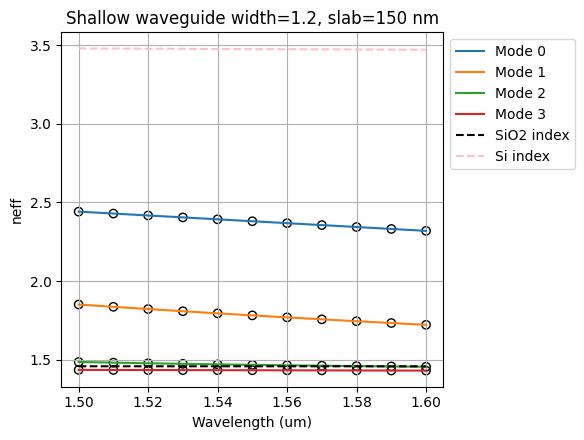

In [21]:
plt.figure(figsize=(7, 4.5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Shallow waveguide width={1.2}, slab={150} nm")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.plot(wavelength, si_index,'k--', color = "pink", label='Si index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('LB01_Shallow_modes.png', bbox_inches='tight')

Since the simulation is performed over multiple wavelengths and multiple supported modes, the resulting effective index is stored as a two-dimensional array, where each column corresponds to a guided mode and each row corresponds to a wavelength sample.

The simulated effective index data was stored and later retrieved in order to avoid repeating computationally expensive mode-solving simulations.

In [22]:
np.save("SOI_Waveguide.npy", {
    "wavelength": wavelength,
    "neff": res_neff
})

In [23]:
data = np.load("SOI_Waveguide.npy", allow_pickle=True).item()

wavelength = data["wavelength"]
neff_SOI = data["neff"] # deep_neff[:, 0] = TE_0
lambda0 = 1.55
wavelengthshift = wavelength-lambda0

The fundamental transverse-electric mode $TE_0$ was selected for dispersion analysis.

In [24]:
neff_TE_0 = neff_SOI[:, 0] # TE_0

A second-order polynomial fitting was applied to the wavelength-dependent effective index in order to approximate its local spectral behavior around the reference wavelength.

The group index was obtained from the first derivative of the effective index with respect to wavelength, allowing the estimation of the modal group velocity.

The chromatic dispersion parameter was extracted from the second derivative of the effective index, which quantifies the wavelength dependence of the group velocity.


In [25]:
coeffs = np.polyfit(wavelengthshift, neff_TE_0.real, 2)

n3, n2, n1 = coeffs
lambda0 = 1.55   # micrometers
c = 3e8          # m/s

# neff en lambda0
neff = n1

# primera derivada en lambda0
dneff_dlambda = n2

# group index
ng = neff - lambda0 * dneff_dlambda

# segunda derivada
d2neff_dlambda2 = 2*n3

# dispersion parameter
D = -(lambda0/c) * d2neff_dlambda2

print(f"n3 = {n3:.2f}")
print(f"n2 = {n2:.2f}")
print(f"n1 = {n1:.2f}")
print(f"Effective index neff = {neff:.2f}")
print(f"Group index ng = {ng:.2f}")
print(f"Dispersion parameter D = {D:.2e}")

n3 = -0.04
n2 = -1.22
n1 = 2.38
Effective index neff = 2.38
Group index ng = 4.28
Dispersion parameter D = 4.17e-10


The fitted polynomial was compared against the simulated effective index samples in order to validate the local approximation around the operating wavelength.

/home/nixtropy/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nixtropy/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


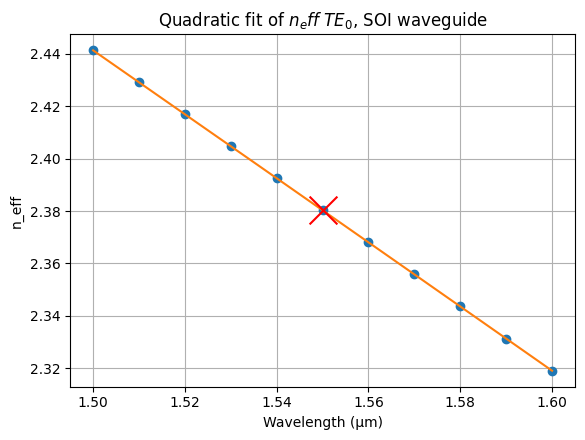

In [26]:
# Evaluar el polinomio
#-----------------------------
# Deep waveguide TE
#-----------------------------

x_fit = np.linspace(wavelengthshift.min(), wavelengthshift.max(), 200)
y_fit = np.polyval(coeffs, x_fit)

plt.figure(figsize=(7, 4.5))
plt.scatter(lambda0, n1, s=400, marker='x', color='red',zorder=5)
plt.plot(wavelength, neff_TE_0, 'o')
plt.plot(x_fit+lambda0, y_fit)
plt.xlabel("Wavelength (µm)")
plt.ylabel("n_eff")
plt.title("Quadratic fit of $n_eff$ $TE_0$, SOI waveguide")
plt.grid(True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig('LO3_Deep_TE_0.png', bbox_inches='tight')